In [16]:
import sys
from pathlib import Path
import torch
import numpy as np
from time import time
from matplotlib import pyplot as plt

# Note: Will need to move HeFESTo_functions.py to nMELTS/utils so it will be ported properly. 

# Handle both notebook and script contexts
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook context
    repo_root = Path.cwd().parent

# Add both src and src/nMELTS to path
src_root = repo_root / "src"
nmelts_root = src_root / "nMELTS"

if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
if str(nmelts_root) not in sys.path:
    sys.path.insert(0, str(nmelts_root))

# Import utilities and API
from nMELTS.utils.math_utils import grid_sample, grid_sample_explicit, mix_compositions
from nMELTS.engine.API import HeFESToEmulatorCPU #, HeFESToEmulatorGPU # This is the iterfaceable model
from nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES
REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES = {v: k for k, v in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.items()}


print("Imports successful!")
print(f"Repository root: {repo_root}")
print(f"nMELTS root: {nmelts_root}")

# Check emulator availability
if HeFESToEmulatorCPU is None:
    print("\nNote: Pre-instantiated emulators not available (model files missing).")
    print("Create HeFESToAPI instances with valid model paths when needed.")
else:
    print("\nEmulators available:")
    print(f"  - HeFESToEmulatorCPU")

Imports successful!
Repository root: c:\Git_Repositories\nMELTS
nMELTS root: c:\Git_Repositories\nMELTS\src\nMELTS

Emulators available:
  - HeFESToEmulatorCPU


In [4]:
# HeFESTo PS Phase Diagram Demo - Load Simulations from HeFESTo dataset, then replicate calculations with emulator

import sys
from pathlib import Path
import numpy as np
import pandas as pd

# Get repo root (from cell 1 setup)
try:
    repo_root = Path(__file__).parent.parent
except NameError:
    repo_root = Path.cwd().parent

# Add builder path for HeFESTo functions
builder_root = repo_root / "src" / "builder"
sys.path.insert(0, str(builder_root))

from HeFESTo.HeFESTo_functions import extract_bulk_properties_from_simulation_dir, load_fort99_componentMoles 

# Define compositions for reference
compositions = {
    'harzburgite_PS': {
    'Si': 3.57887,
    'Mg': 5.64233,
    'Fe': 0.58052,
    'Ca': 0.07969,
    'Al': 0.09740,
    'Na': 0.00160,
    'Cr': 0.01960,
    'O': 13.63947
    },

    'DMM_PS': {
    'Si': 3.79222,
    'Mg': 4.88475,
    'Fe': 0.57874,
    'Ca': 0.28734,
    'Al': 0.39685,
    'Na': 0.02197,
    'Cr': 0.03813,
    'O': 14.00450
    },
}

# Load HeFESTo PS simulations - use absolute paths
hefesto_workspace = repo_root / "notebooks" / "demoHeFESToData"

sim_paths = {
    'harzburgite_PS': hefesto_workspace / 'htz_PS',
    'DMM_PS': hefesto_workspace / 'DMM_PS',
}

# Dictionary to store DataFrames
sim_tables = {}
comp_tables = {}
mass_tables = {}
indexer = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer # Object used to manipulate emulator inputs and outputs

print("Loading HeFESTo simulations...\n")

for sim_name, sim_path in sim_paths.items():
    try:
        print(f"Loading {sim_name} from {sim_path}...")
        props = extract_bulk_properties_from_simulation_dir(str(sim_path))
        comp_tables[sim_name] = load_fort99_componentMoles(str(sim_path), indexer)
        # convert component moles (B, C) to phase masses (B, P)
        _, mass_tables[sim_name] = HeFESToEmulatorCPU.isentropic_emulator.make_phase_tables(torch.tensor(comp_tables[sim_name], dtype=torch.float32))


        # Build each table section explicitly so no columns get lost in a dict update.
        n_rows = len(props['T(K)'])
        base_df = pd.DataFrame({
            'T(K)': np.asarray(props['T(K)']).reshape(n_rows),
            'P(GPa)': np.asarray(props['P(GPa)']).reshape(n_rows),
            'VS(km/s)': np.asarray(props['VS(km/s)']).reshape(n_rows),
            'VP(km/s)': np.asarray(props['VP(km/s)']).reshape(n_rows),
            'rho(g/cm^3)': np.asarray(props['rho(g/cm^3)']).reshape(n_rows),
            'VB(km/s)': np.asarray(props['VB(km/s)']).reshape(n_rows),
            'VSQ(km/s)': np.asarray(props['VSQ(km/s)']).reshape(n_rows),
            'VPQ(km/s)': np.asarray(props['VPQ(km/s)']).reshape(n_rows),
            'H(kJ/g)': np.asarray(props['H(kJ/g)']).reshape(n_rows),
            'S(J/g/K)': np.asarray(props['S(J/g/K)']).reshape(n_rows),
            'alpha(1e5_K^-1)': np.asarray(props['alpha(1e5_K^-1)']).reshape(n_rows),
            'cp(J/g/K)': np.asarray(props['cp(J/g/K)']).reshape(n_rows),
            'KS(GPa)': np.asarray(props['KS(GPa)']).reshape(n_rows),
        })

        component_df = pd.DataFrame(index=base_df.index)
        for i, comp_name in enumerate(props['component_names']):
            component_df[f'comp_{comp_name}'] = np.asarray(props['component_moles'][:, i]).reshape(n_rows)

        df = pd.concat([base_df, component_df], axis=1) #bulk_df,
        sim_tables[sim_name] = df

        print(f"  -> Loaded {len(df)} rows")
        print(f"  -> Columns: {list(df.columns)[:8]}...")
        print()

    except Exception as e:
        print(f"ERROR loading {sim_name}: {e}\n")

# Display summary
print("="*70)
print("SUMMARY OF LOADED SIMULATIONS")
print("="*70)

emulated_components = {}
emulated_mass_tables = {}

emulated_components_NN = {}
emulated_mass_tables_NN = {}

for sim_name, df in sim_tables.items():
    

    comp = compositions[sim_name]
    headers = []
    print(f"\n{sim_name} composition: {comp}")
    comp_array = np.zeros((1, len(comp)), dtype=np.float32)
    for idx, (element, value) in enumerate(comp.items()):
        headers.append(element)
        comp_array[0, idx] = value
        
    input_grid = np.concatenate([sim_tables[sim_name][['P(GPa)', 'S(J/g/K)']].to_numpy(), np.tile(comp_array, (sim_tables[sim_name].shape[0], 1))], axis=1)
    print(f"Input grid shape: {input_grid.shape}")

    headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', ] + headers
    #features_tensor = HeFESToEmulatorCPU.parse_input(input_grid, headers=headers)
    output = HeFESToEmulatorCPU.ForwardMB(
        input_grid,
        headers=headers,
        outputs=['component_moles', 'phase_tables']
    )

    emulated_components[sim_name], (_, emulated_mass_tables[sim_name]) = output['component_moles'], output['phase_tables']

    print(f"\n{sim_name}:")
    print(f"  Shape: {df.shape}")
    print(f"  P range: {df['P(GPa)'].min():.2f} - {df['P(GPa)'].max():.2f} GPa")
    print(f"  T range: {df['T(K)'].min():.0f} - {df['T(K)'].max():.0f} K")
    print(f"  Description:\n{df.describe().to_string()}")

Loading HeFESTo simulations...

Loading harzburgite_PS from c:\Git_Repositories\nMELTS\notebooks\demoHeFESToData\htz_PS...
  -> Loaded 4089 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

Loading DMM_PS from c:\Git_Repositories\nMELTS\notebooks\demoHeFESToData\DMM_PS...
[WARNING] Component alpha-iron is present in fort.99 but not found in indexer!
  -> Loaded 4089 rows
  -> Columns: ['T(K)', 'P(GPa)', 'VS(km/s)', 'VP(km/s)', 'rho(g/cm^3)', 'VB(km/s)', 'VSQ(km/s)', 'VPQ(km/s)']...

SUMMARY OF LOADED SIMULATIONS

harzburgite_PS composition: {'Si': 3.57887, 'Mg': 5.64233, 'Fe': 0.58052, 'Ca': 0.07969, 'Al': 0.0974, 'Na': 0.0016, 'Cr': 0.0196, 'O': 13.63947}
Input grid shape: (4089, 10)
Adding ferric column...

harzburgite_PS:
  Shape: (4089, 85)
  P range: 0.00 - 140.00 GPa
  T range: 1217 - 3635 K
  Description:
              T(K)      P(GPa)     VS(km/s)     VP(km/s)  rho(g/cm^3)     VB(km/s)    VSQ(km/s)    VPQ(km/s

In [10]:

# Phase stack animation: ground truth vs emulated, cycling through isentropes in
# ascending entropy order.  Requires cells 1 and 2 (sim_tables, mass_tables,
# emulated_mass_tables, phase_order helpers).

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from src.nMELTS.config.constants import HEFESTO_ABBREVIATION_TO_SHORT_NAMES

# --- Select composition ---
sim_name = 'DMM_PS'   # options:'DMM_PS', 'harzburgite_PS' # Or: Do your own PS grid calculation in HeFESTo! You'll need to input the chemistry in the dictionaries above, The above block doesn't read input composition.

INDEX_TO_PHASE = {
    1:'plg', 2:'sp', 3:'opx', 4:'c2c', 5:'cpx', 6:'wo', 7:'pwo', 8:'gt', 9:'cpv',
    10:'ol', 11:'wa', 12:'ri', 13:'il', 14:'pv', 15:'ppv', 16:'cf', 17:'nal', 18:'mw',
    19:'qtz', 20:'coes', 21:'st', 22:'apbo', 23:'ky', 24:'neph', 25:'fea', 26:'feg', 27:'fee'
}

PHASE_TO_INDEX = {v: k for k, v in INDEX_TO_PHASE.items()}

phase_names = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.all_phases
mass_phasedict = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.mass_phasedict


IP_PYROLITE = [19,20,21,22,10,11,12,18,14,15,13,8,16,9,3,4,5,1,2,23,24,17,25,26,27,6,7] # Convention of HeFESTo creators. Table comp names

phase_order = []

for i, idx in enumerate(IP_PYROLITE):
    #print(f"{i}: {INDEX_TO_PHASE[idx]}")
    shortname = INDEX_TO_PHASE[idx]
    if shortname in HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values():
        phase_order.append(np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.keys()))[np.array(list(HEFESTO_ABBREVIATION_TO_SHORT_NAMES.values())) == shortname][0])

# Now stack phase abundances in this order (bottom to top) using the following script! Use the matplotlib.animation.FuncAnimation function to animate  

# -------------------------------------------------------
# Phase color rules (named colors, grouped by mineral family)
# -------------------------------------------------------
def phase_colors():
    col = {}

    # Silica polymorphs
    for p in ['qtz', 'coes', 'st', 'apbo', 'cacl']:
        col[p] = 'dimgray'

    # Plagioclase / feldspars (light)
    for p in ['plg', 'pwo', 'wo', 'neph']:
        col[p] = 'lightgray'

    # Aluminum silicates & Al-bearing (distinct from general silica)
    for p in ['ky', 'nal']:
        col[p] = 'mediumpurple'

    # Pyroxenes
    for p in ['opx', 'cpx', 'c2c']:
        col[p] = 'steelblue'

    # Spinel
    col['sp'] = 'brown'

    # Garnet
    col['gt'] = 'red'

    # Olivine + high-P polymorphs
    for p in ['ol', 'wa', 'ri', 'il']:
        col[p] = 'forestgreen'

    # Perovskite family (varying yellow/beige)
    col['pv']  = 'khaki'
    col['ppv'] = 'goldenrod'
    col['cf']  = 'wheat'
    col['cpv'] = 'tan'

    # Iron phases (native iron/allotropes)
    for p in ['fea', 'feg', 'fee']:
        col[p] = 'sienna'

    # Ferropericlase / magnesiowüstite (if present)
    col['mw'] = 'magenta'

    # Fallback for anything unexpected
    return col



df = sim_tables[sim_name].reset_index(drop=True)

# Unique entropy values in ascending order
unique_entropies = np.sort(df['S(J/g/K)'].round(4).unique())
n_isentropes = len(unique_entropies)

# --- Convert mass tables to float32 numpy fractions (0–1).
# make_phase_tables returns phaseMassNorm in percentage (0–100), so divide by 100.
def _to_numpy(t):
    if hasattr(t, 'detach'):
        return t.detach().cpu().numpy().astype(np.float32)
    return np.asarray(t, dtype=np.float32)

gt = _to_numpy(mass_tables[sim_name]) / 100.0        # (n_rows, n_phases), fractions
em = _to_numpy(emulated_mass_tables[sim_name]) / 100.0

# --- Build ordered (long_name, short_abbrev) list via IP_PYROLITE ---
ordered_phases = []
for hf_idx in IP_PYROLITE:
    abbrev = INDEX_TO_PHASE[hf_idx]
    if abbrev not in HEFESTO_ABBREVIATION_TO_SHORT_NAMES:
        continue
    long_name = HEFESTO_ABBREVIATION_TO_SHORT_NAMES[abbrev]
    if long_name in mass_phasedict:
        ordered_phases.append((long_name, abbrev))

colors = phase_colors()

# --- Draw a single stacked-area panel ---
def _draw_stack(ax, data, row_idx, title):
    """
    data     : (n_rows, n_phases) float32 array in [0, 1] (gt or em)
    row_idx  : integer row indices into df / data, already sorted by pressure
    """
    ax.cla()
    pres = df['P(GPa)'].values[row_idx]
    bottoms = np.zeros(len(pres), dtype=np.float32)
    for long_name, abbrev in ordered_phases:
        col = mass_phasedict[long_name]
        vals = np.clip(data[row_idx, col], 0.0, None)
        top = bottoms + vals
        ax.fill_between(pres, bottoms, top,
                        facecolor=colors.get(abbrev, '#aaaaaa'),
                        edgecolor='k', linewidth=0.4)
        peak = float(np.nanmax(vals))
        if peak > 0.03:
            band = vals > 0.35 * peak
            if band.any():
                x_c = np.average(pres[band], weights=vals[band])
                y_c = np.average(0.5 * (bottoms[band] + top[band]), weights=vals[band])
                ax.text(x_c, y_c, abbrev, ha='center', va='center',
                        fontsize=7, clip_on=True)
        bottoms = top
    ax.set_ylim(0.0, 1.0)
    ax.set_xlim(pres.min(), pres.max())
    ax.set_ylabel('Phase fraction')
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.2)



# --- Build figure ---
fig, (ax_gt, ax_em) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
ax_em.set_xlabel('Pressure (GPa)')
title_obj = fig.suptitle('', fontsize=13)

def update(frame):
    s_val = unique_entropies[frame]
    row_idx = np.where(df['S(J/g/K)'].round(4).values == s_val)[0]
    row_idx = row_idx[np.argsort(df['P(GPa)'].values[row_idx])]  # sort by pressure
    _draw_stack(ax_gt, gt, row_idx, f'Ground Truth  |  S = {s_val:.4f} J/g/K')
    _draw_stack(ax_em, em, row_idx, f'Emulated with Mass Balancing |  S = {s_val:.4f} J/g/K')
    title_obj.set_text(
        f'{sim_name}  —  Isentrope {frame + 1}/{n_isentropes}  (S ascending)'
    )
    
    return []

anim = animation.FuncAnimation(
    fig, update,
    frames=n_isentropes,
    interval=300,
    blit=False,
    repeat=True,
)

plt.close(fig)
anim.save('PS_Phase_Fractions.gif', writer='pillow', dpi = 300)
HTML(anim.to_jshtml())

# For saving the first frame

#fig, (ax_gt, ax_em) = plt.subplots(2, 1, figsize=(12, 9), sharex=True, constrained_layout=True)
#ax_em.set_xlabel('Pressure (GPa)')
#title_obj = fig.suptitle('', fontsize=13)

#update(0)
#plt.savefig(f'{sim_name}_isentrope_GTing.png', dpi=300) # save first frame as static image for reference
#plt.close()




**Demo for Ji Ching's Workflow**

Step 1+2: Get Isentropes given an adiabatic potential temperature

Two cases: 

    1: Many isentropes for constant composition
    
    2: Freely varied composition
    

[INFO] Looking for HeFESTo model at: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPT.tar
Attempting to load model from .pt file: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPT.tar
Legacy format failed, attempting to load as zip format: [enforce fail at inline_container.cc:174] . file in archive is not in a subdirectory: config.json
ml_indexer.molar_epsilon = 0
YOU HAVE INSTANTIATED A LINEAR MOLE HEAD WITH SOFTPLUS ACTIVATION.
Registered molar_epsilon buffer with value: 0.0
Attempting to load model from .pt file: c:\Git_Repositories\nMELTS\src\nMELTS\engine\TrainedModels\HeFESTo_Adiabats\HeFESTo_adiabats_NPS.tar
Legacy format failed, attempting to load as zip format: [enforce fail at inline_container.cc:174] . file in archive is not in a subdirectory: config.json
ml_indexer.molar_epsilon = 0
YOU HAVE INSTANTIATED A LINEAR MOLE HEAD WITH SOFTPLUS ACTIVATION.
Registered molar_epsilon buffer 

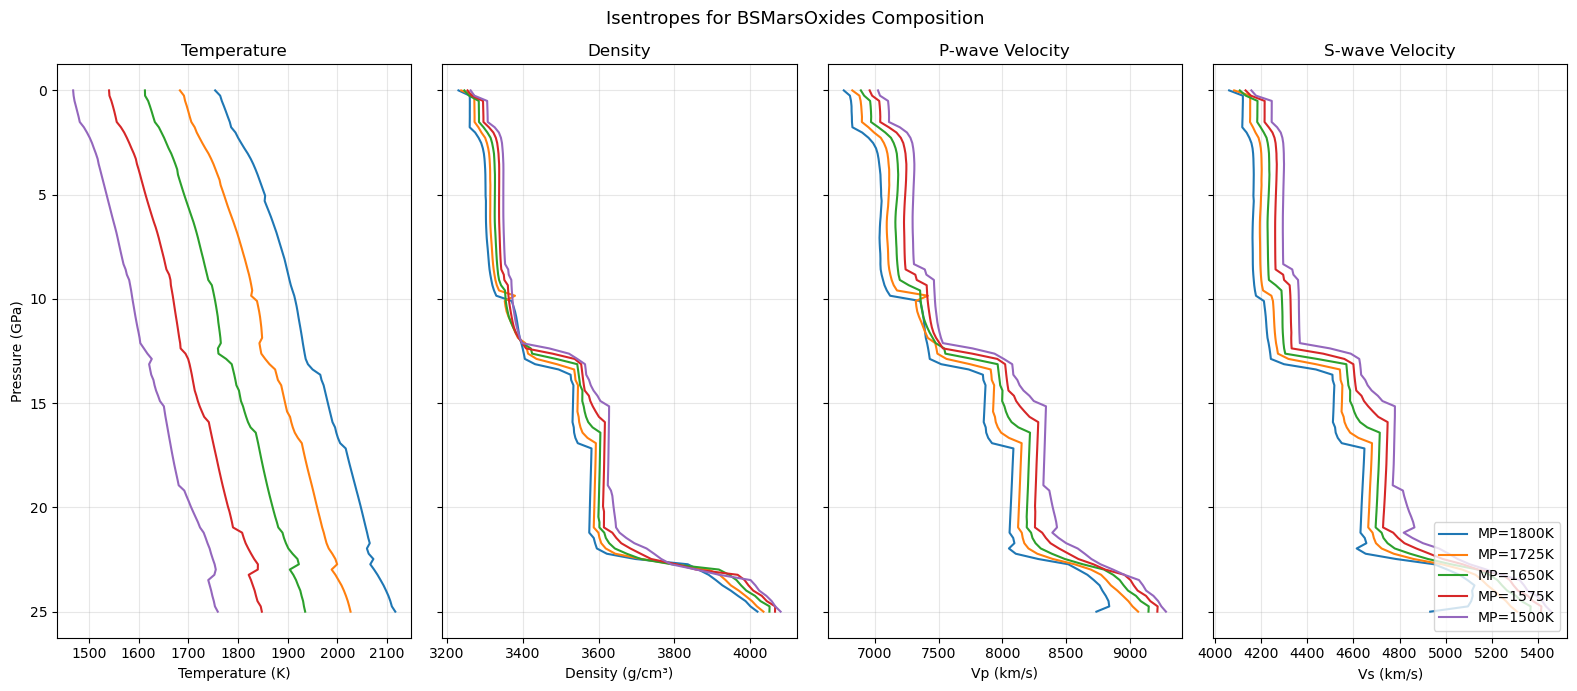

In [ ]:
# Get Multiple Isentropes for one composition

import time
import importlib
import src.nMELTS.engine.API as API
importlib.reload(API)

BSMarsOxides = { #Yoshizaki and McDonough, 2020
    'SiO2':45.5,
    'Al2O3': 3.59,
    'FeO': 13.0, # Fe Speciation ballparked for Fe3 = 0.1Fetot
    'Fe2O3': 2.1,
    'MgO': 31.0,
    'CaO': 2.88,
    'Na2O':0.59,
    'Cr2O3':0.88
    }

BSEarthOxides = { # McDonough and Sun, 1995
    'SiO2':45.0,
    'Al2O3': 4.45,
    'FeO': 7.75, # Fe Speciation ballparked for Fe3 = 0.03 Fetot
    'Fe2O3': 0.35,
    'MgO': 37.8,
    'CaO': 3.55,
    'Na2O':0.36,
    'Cr2O3':0.38
    }

potential_temperatures = np.linspace(1800, 1500, 5) # K
pressures = np.linspace(0,25,100)

headers = ['P(GPa)(System_main)', 'T(K)(System_main)'] + list(BSMarsOxides.keys())
comp_array = np.array([0,0] + list(BSMarsOxides.values())).reshape(1, -1).astype(np.float32) # Always 2D, even if one row.

# Headers are inteligent: You can do oxides weight percents with both Fe2O3 and FeO, or Elemental mole fraction using Fe3+ or O. 

begin_time = time.time()
temperature_grid, pressure_grid, adiabat_properties = API.HeFESToEmulatorCPU.get_isentrope(
        features = comp_array,
        headers = headers,
        pressures = pressures,
        potential_temperatures = potential_temperatures,
        properties = ['entropy_by_mass', 'density', 'p_wave_velocity', 's_wave_velocity', 'isothermal_bulk_modulus_reuss'])

end_time = time.time()
print(f"Emulator Execution time for {len(potential_temperatures)*len(pressures)} assemblagess: {end_time - begin_time} seconds")

fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)

prop_configs = [
    (temperature_grid,                        'Temperature (K)',  'Temperature'),
    (adiabat_properties['density'],           'Density (g/cm³)',  'Density'),
    (adiabat_properties['p_wave_velocity'],   'Vp (km/s)',        'P-wave Velocity'),
    (adiabat_properties['s_wave_velocity'],   'Vs (km/s)',        'S-wave Velocity'),
]

for ax, (data, xlabel, title) in zip(axes, prop_configs):
    for i, mpT in enumerate(potential_temperatures):
        ax.plot(data[i], pressure_grid[i], label=f'MP={mpT:.0f}K')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Pressure (GPa)')
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')
fig.suptitle('Isentropes for BSMarsOxides Composition', fontsize=13)
plt.tight_layout()
plt.show()

Keys: ['Al2O3', 'CaO', 'Cr2O3', 'Fe2O3', 'FeO', 'MgO', 'Na2O', 'SiO2']
Mixed: {'Al2O3': 0.044660778803693305, 'CaO': 0.03562826174227218, 'Cr2O3': 0.0038137294259333607, 'Fe2O3': 0.0035126455238859897, 'FeO': 0.07778000802890407, 'MgO': 0.3793657165796869, 'Na2O': 0.0036130068245684467, 'SiO2': 0.45162585307105585}
Keys: ['Al2O3', 'CaO', 'Cr2O3', 'Fe2O3', 'FeO', 'MgO', 'Na2O', 'SiO2']
Mixed: {'Al2O3': 0.04251205989139767, 'CaO': 0.033954469362762, 'Cr2O3': 0.005070463836578814, 'Fe2O3': 0.007908745746290021, 'FeO': 0.09098519689971704, 'MgO': 0.3623824349131658, 'Na2O': 0.004191571473660412, 'SiO2': 0.45299505787642835}
Keys: ['Al2O3', 'CaO', 'Cr2O3', 'Fe2O3', 'FeO', 'MgO', 'Na2O', 'SiO2']
Mixed: {'Al2O3': 0.040363340979102026, 'CaO': 0.03228067698325182, 'Cr2O3': 0.006327198247224266, 'Fe2O3': 0.01230484596869405, 'FeO': 0.10419038577053, 'MgO': 0.3453991532466447, 'Na2O': 0.004770136122752377, 'SiO2': 0.4543642626818008}
Keys: ['Al2O3', 'CaO', 'Cr2O3', 'Fe2O3', 'FeO', 'MgO', 'Na2O', 

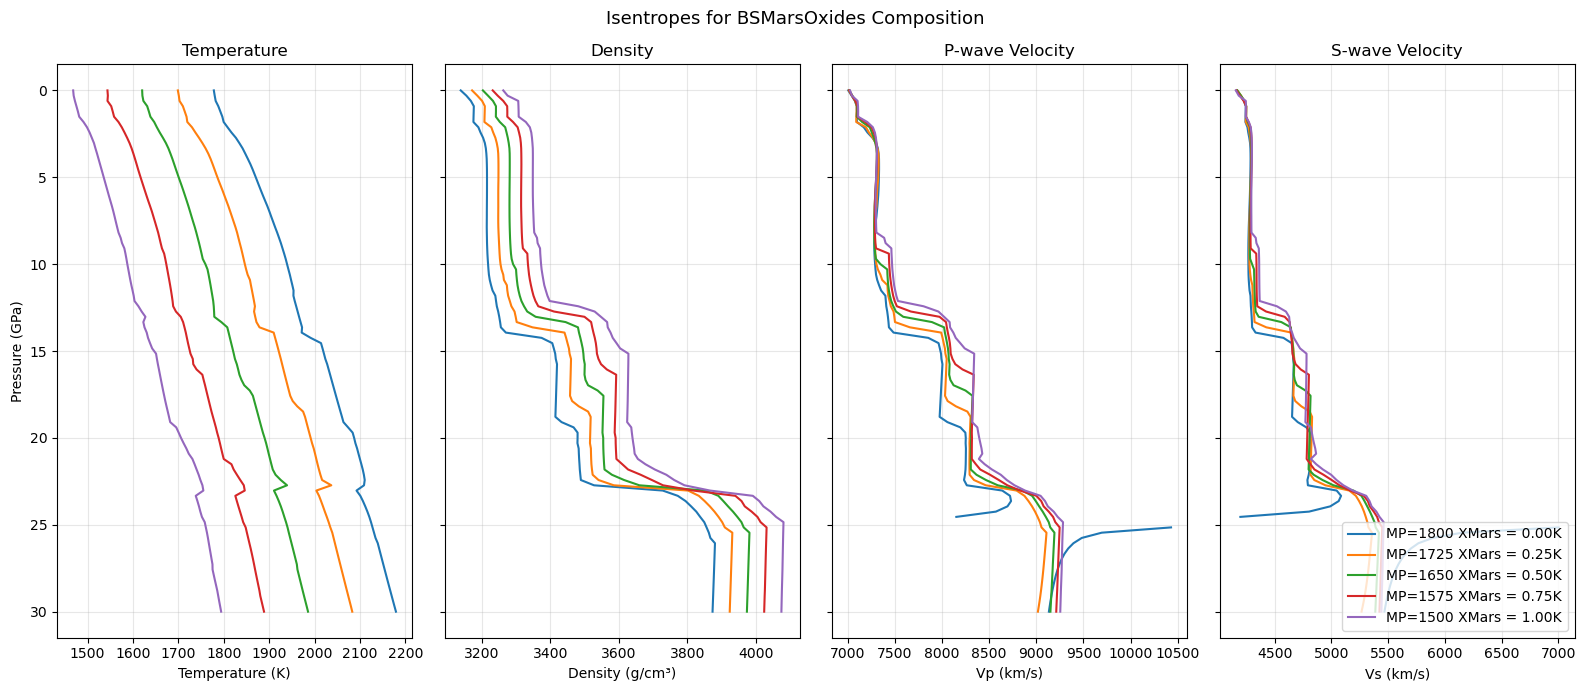

In [ ]:
from time import time


# Get Isentropes in parallel for arbitrary temperature-composition combination


BSMarsOxides = { #Yoshizaki and McDonough, 2020
    'SiO2':45.5,
    'Al2O3': 3.59,
    'FeO': 13.0, # Fe Speciation ballparked for Fe3 = 0.1Fetot
    'Fe2O3': 2.1,
    'MgO': 31.0,
    'CaO': 2.88,
    'Na2O':0.59,
    'Cr2O3':0.88
    }

BSEarthOxides = { # McDonough and Sun, 1995
    'SiO2':45.0,
    'Al2O3': 4.45,
    'FeO': 7.75, # Fe Speciation ballparked for Fe3 = 0.03 Fetot
    'Fe2O3': 0.35,
    'MgO': 37.8,
    'CaO': 3.55,
    'Na2O':0.36,
    'Cr2O3':0.38
    }

potential_temperatures = np.linspace(1800, 1500, 5) # K
pressures = np.linspace(0,30,100)

mars_fraction = np.linspace(0, 1, len(potential_temperatures)).tolist() # 0 to 100% BSMarsOxides in 25% increments

headers = ['P(GPa)(System_main)', 'T(K)(System_main)']

# Fancy way to cook up mixes. You could just as well load a .csv with compositions or change a parameter for each composition in a matrix from last loop for MCMC
comp_array = np.zeros((len(potential_temperatures), 2+len(BSEarthOxides)), dtype=np.float32) # Always 2D, even if one row
for i, fraction in enumerate(mars_fraction):
    compositions = mix_compositions([BSEarthOxides, BSMarsOxides],  [1-fraction, fraction])# Mixes Chemical Dictionaries
    if i == 0:
        headers += list(compositions.keys())
    comp_array[i, 2:] = list(compositions.values())

comp_array[:,1] = potential_temperatures

# Headers are inteligent: You can do oxides weight percents with both Fe2O3 and FeO, or Elemental mole fraction using Fe3+ or O. 

begin_time = time()
temperature_grid, pressure_grid, adiabat_properties = API.HeFESToEmulatorCPU.get_isentrope( # For custom X-T pairs, do not use potentail temperature argument
        features = comp_array,
        headers = headers,
        pressures = pressures,
        properties = ['entropy_by_mass', 'density', 'p_wave_velocity', 's_wave_velocity', 'isothermal_bulk_modulus_reuss'])

end_time = time()
print(f"Emulator Execution time for {len(potential_temperatures)*len(pressures)} assemblagess: {end_time - begin_time} seconds")

fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=True)

prop_configs = [
    (temperature_grid,                        'Temperature (K)',  'Temperature'),
    (adiabat_properties['density'],           'Density (g/cm³)', 'Density'),
    (adiabat_properties['p_wave_velocity'],   'Vp (km/s)',        'P-wave Velocity'),
    (adiabat_properties['s_wave_velocity'],   'Vs (km/s)',        'S-wave Velocity'),
]

for ax, (data, xlabel, title) in zip(axes, prop_configs):
    for i, mpT in enumerate(potential_temperatures):
        ax.plot(data[i], pressure_grid[i], label=f'MP={mpT:.0f} XMars = {mars_fraction[i]:.2f}K')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Pressure (GPa)')
axes[0].invert_yaxis()
axes[-1].legend(loc='lower right')
fig.suptitle('Isentropes for BSMarsOxides Composition', fontsize=13)
plt.tight_layout()
plt.show()


WOW what the heck is going on with the p/s-wave velocities for the 1800K potential temp BSE earth adiabat?? Beautiful Hyperbolic relationship to asymptote at 25 MPa. Is this a burnman thing? The NN temperatures look fine. 

Adding ferric column...
Adding ferric column...


Processing batches of size 32768: 100%|██████████| 137/137 [11:53:52<00:00, 312.64s/it]     


Time to run 4500000 assemblages: 42834.37 seconds, 9.52e-03 seconds per assemblage


MovieWriter ffmpeg unavailable; using Pillow instead.


Saved: Phase_Diagram_Demo.gif
time to animate phase diagram: 53.14 seconds


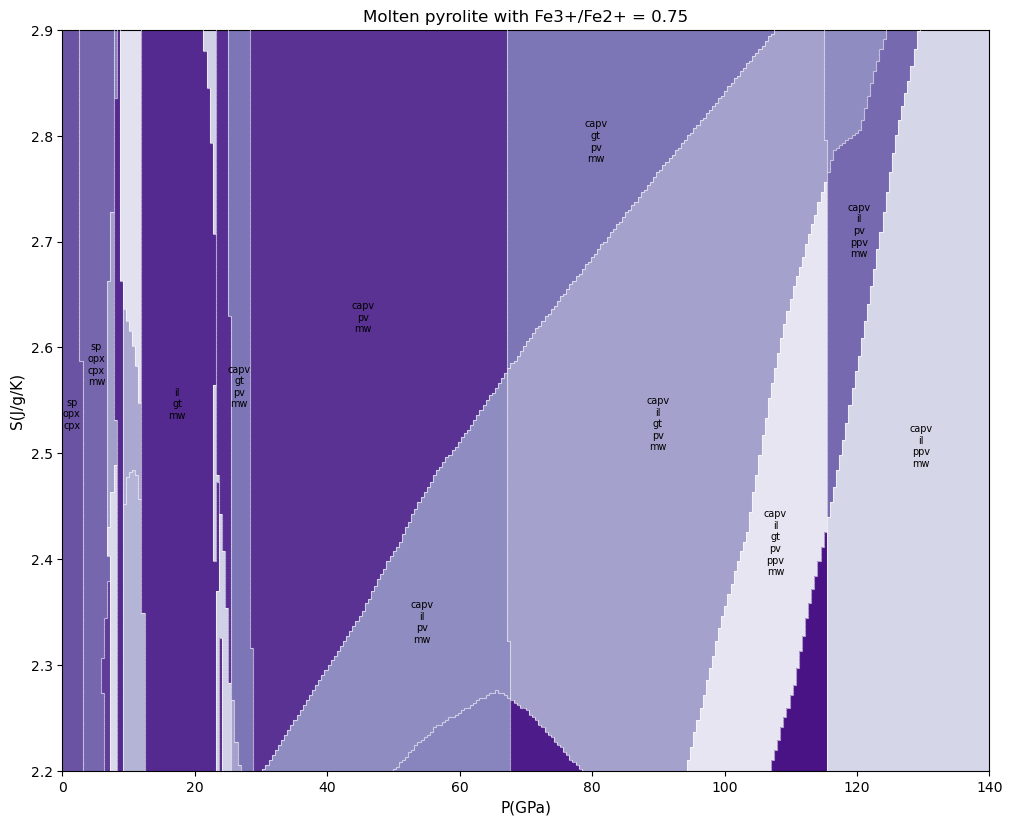

In [14]:
# Animated Phase Diagrams!
import time

input_dict = { #Caracas et al., 2019
    'Si':24,
    'Al':3,
    'Fe':4,
    'Mg':30,
    'Ca':2,
    'Na':1,
}


headers = []
comp_array = np.zeros((1, len(input_dict)), dtype=np.float32)
for idx, (element, value) in enumerate(input_dict.items()):
    headers.append(element)
    comp_array[0, idx] = value
    
inputs = grid_sample([[0,140,300],[2.2,2.9,300],[89.5,90.5,50]], comp_array)

independent_variables = ['P(GPa)', 'S(J/g/K)', 'O']

headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', 'O'] + headers

tab = HeFESToEmulatorCPU.parse_input(inputs, headers=headers)[0]

ferrous_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe')+2
ferric_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe3')+2
Ferric_Ratio = tab[:,ferric_column]/ tab[:,ferrous_column]

with torch.no_grad():
    begin_time = time.time()
    threeGrid = HeFESToEmulatorGPU.ForwardMB(inputs, headers=headers, outputs=['phase_moles'])
    end_time = time.time( )
    print(f"Time to run {inputs.shape[0]} assemblages: {end_time - begin_time:.2f} seconds, {(end_time - begin_time) / inputs.shape[0]:.2e} seconds per assemblage")

    independents = inputs[:,:3]
    independents[:,2] = Ferric_Ratio

    animate_phase_diagram(
        coords= independents,
        phases= (threeGrid['phase_moles'] > 0),
        phase_names= [REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES[phase] for phase in HeFESToEmulatorGPU.isentropic_emulator.ml_indexer.all_phases],
        axis_names= independent_variables,
        title_template='Molten pyrolite with Fe3+/Fe2+ = {}' ,
        save_path= 'Phase_Diagram_Demo.gif',
    ) 

print(f"time to animate phase diagram: {time.time()-end_time:.2f} seconds")


In [ ]:
with torch.no_grad():
    begin_time = time.time()
    threeGrid = HeFESToEmulatorGPU.ForwardMB(inputs, headers=headers, outputs=['phase_moles'])
    end_time = time.time( )
    print(f"Time to run {inputs.shape[0]} assemblages: {end_time - begin_time:.2f} seconds, {(end_time - begin_time) / inputs.shape[0]:.2e} seconds per assemblage")

    independents = inputs[:,:3]
    independents[:,2] = Ferric_Ratio

    animate_phase_diagram(
        coords= independents,
        phases= (threeGrid['phase_moles'] > 0),
        phase_names= [REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES[phase] for phase in HeFESToEmulatorGPU.isentropic_emulator.ml_indexer.all_phases],
        axis_names= independent_variables,
        title_template='Molten pyrolite with Fe3+/Fe2+ = {}' ,
        save_path= 'Phase_Diagram_Demo.gif')


MovieWriter ffmpeg unavailable; using Pillow instead.


Adding ferric column...


Processing batches of size 32768:   0%|          | 0/137 [00:00<?, ?it/s]

Phase forcing did not satisfy mass balance even after 3 iterations


Processing batches of size 32768:  42%|████▏     | 57/137 [01:04<01:30,  1.13s/it]


KeyboardInterrupt: 

In [ ]:
HEFESTO_ABBREVIATION_TO_SHORT_NAMES

mappingproxy({'plg': 'plagioclase',
              'sp': 'spinel',
              'ol': 'olivine',
              'wa': 'wadsleyite',
              'ri': 'ringwoodite',
              'opx': 'orthopyroxene',
              'cpx': 'clinopyroxene',
              'wo': 'wollastonite',
              'pwo': 'pseudowollastonite',
              'c2c': 'hp-clinopyroxene',
              'cpv': 'ca-perovskite',
              'il': 'akimotoite',
              'mgil': 'mg-akimotoite',
              'feil': 'fe-akimotoite',
              'gt': 'garnet',
              'qtz': 'quartz',
              'coes': 'coesite',
              'st': 'stishovite',
              'apbo': 'alpha-pbo-type-sio2',
              'seif': 'seifertite',
              'pv': 'bridgmanite',
              'ppv': 'post-perovskite',
              'fp': 'ferropericlase',
              'cf': 'ca-ferrite',
              'nal': 'nal-phase',
              'ky': 'kyanite',
              'neph': 'nepheline',
              'an': 'anorthite',

In [ ]:
input_dict = {
    'Si':24,
    'Al':3,
    'Fe':4,
    'Mg':30,
    'Ca':2,
    'Na':1,
}


headers = []
comp_array = np.zeros((1, len(input_dict)), dtype=np.float32)
for idx, (element, value) in enumerate(input_dict.items()):
    headers.append(element)
    comp_array[0, idx] = value
    
independent_variables = ['P(GPa)', 'S(J/g/K)', 'O']

headers = ['P(GPa)(System_main)', 'S(J/g/K)(System_main)', 'O'] + headers

example_input = grid_sample([[20,20,1],[2.5,2.5,1],[89,91,50]], comp_array)
tab = HeFESToEmulatorCPU.parse_input(example_input, headers=headers)[0]

ferrous_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe')+2
ferric_column = HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.Elkeys.index('Fe3')+2
print(tab[:,ferric_column]/ tab[:,ferrous_column])



Adding ferric column...
tensor([0.0000, 0.0204, 0.0408, 0.0612, 0.0816, 0.1020, 0.1224, 0.1429, 0.1633,
        0.1837, 0.2041, 0.2245, 0.2449, 0.2653, 0.2857, 0.3061, 0.3265, 0.3469,
        0.3673, 0.3878, 0.4082, 0.4286, 0.4490, 0.4694, 0.4898, 0.5102, 0.5306,
        0.5510, 0.5714, 0.5918, 0.6122, 0.6327, 0.6531, 0.6735, 0.6939, 0.7143,
        0.7347, 0.7551, 0.7755, 0.7959, 0.8163, 0.8367, 0.8571, 0.8776, 0.8980,
        0.9184, 0.9388, 0.9592, 0.9796, 1.0000])


In [29]:
torch.pi

3.141592653589793

GPU: 128
Adding ferric column...
[INFO] Adding 'chem_out' to outputs for temperature calculation.
[INFO] Adding 'phase_moles' to outputs for temperature calculation.
0.0000 IO time
Property 'molar_entropy':
torch.Size([128, 18])
tensor([[717.3875, 378.9681, 383.7855,  ...,      nan,  81.0578,  75.0898],
        [719.4812, 375.6087, 383.6117,  ...,      nan,  80.9527,  74.9787],
        [     nan,      nan, 385.3811,  ...,      nan,  81.1734,  75.2120],
        ...,
        [     nan,      nan,      nan,  ...,      nan,  99.4282,  93.8858],
        [     nan,      nan,      nan,  ...,      nan,  99.5292,  93.9726],
        [     nan,      nan,      nan,  ...,      nan,  99.6308,  94.0595]],
       device='cuda:0', dtype=torch.float64)
torch.Size([128, 18])
tensor([[ 8.7880e-02,  1.2553e-05,  8.0582e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2410e-02,  1.6344e-04,  7.4020e-01,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.000

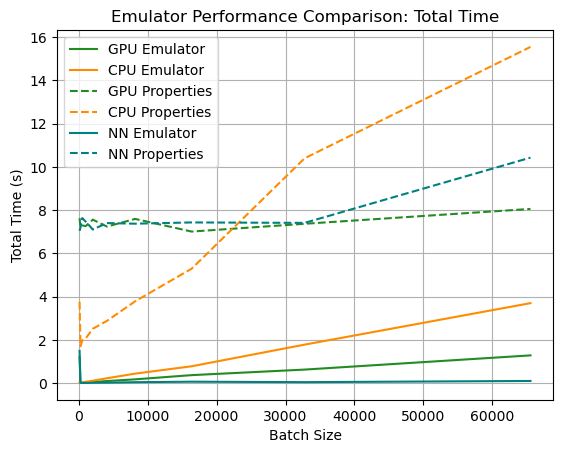

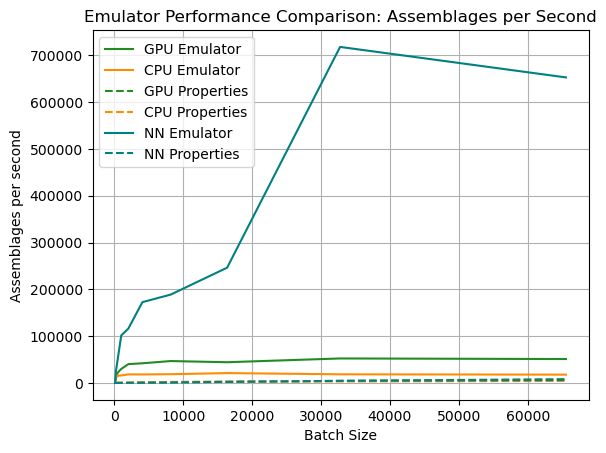

In [ ]:
### Performance Testing

import time



def example_array(batch_size):
    pressures = np.linspace(0,140, batch_size)
    headers = []
    comp_array = np.zeros((1, len(input_dict)), dtype=np.float32)
    for idx, (element, value) in enumerate(input_dict.items()):
        headers.append(element)
        comp_array[0, idx] = value
        
    input_grid = np.concatenate([pressures.reshape(-1, 1), np.tile(comp_array, (len(pressures), 1))], axis=1)

    headers = ['P(GPa)'] + headers

    return input_grid, headers

batch_sizes = np.append(np.linspace(128, 2**15, 10, dtype=int), 2**np.linspace(15,18, 20))

GPU_emulator = []
CPU_emulator = []
NN_emulator = []
GPU_properties = []
CPU_properties = []
NN_properties = []


# first GPU
for batch_size in batch_sizes:
    print(f'GPU: {batch_size}')
    input_array, headers = example_array(batch_size)

    begin_emulator = time.time()
    output = HeFESToEmulatorGPU.ForwardMB(torch.tensor(input_array, dtype=torch.float32, device='cuda'), headers=headers, outputs=['component_moles', 'temperature'])
    end_emulator = time.time()
    GPU_emulator.append(end_emulator - begin_emulator)

    PT = torch.concatenate([torch.tensor(input_array[:,0], dtype=torch.float32, device='cuda').reshape(-1, 1), torch.tensor(output['temperature'], dtype=torch.float32, device='cuda').reshape(-1, 1)], dim=1)

    begin_properties = time.time()
    print(f"{begin_properties - end_emulator:.4f} IO time")
    for i in range(5):
        print(f"Property calculation {i+1}: {time.time() - begin_properties:.4f} seconds")
        output_properties = HeFESToEmulatorGPU.get_property_burnman_vectorized_from_assemblage(torch.tensor(output['component_moles'], dtype=torch.float32, device='cuda'), PT=PT)
    GPU_properties.append(time.time() - begin_properties)

"""for batch_size in batch_sizes:
    print(f'GPU: {batch_size}')
    input_array, headers = example_array(batch_size)

    begin_emulator = time.time()
    output = HeFESToEmulatorGPU.ForwardNN(torch.tensor(input_array, dtype=torch.float32, device='cuda'), headers=headers, outputs=['component_moles', 'temperature'])
    end_emulator = time.time()
    NN_emulator.append(end_emulator - begin_emulator)

    PT = torch.concatenate([torch.tensor(input_array[:,0], dtype=torch.float32, device='cuda').reshape(-1, 1), torch.tensor(output['temperature'], dtype=torch.float32, device='cuda').reshape(-1, 1)], dim=1)

    begin_properties = time.time()
    print(f"{begin_properties - end_emulator:.4f} IO time")
    output_properties = HeFESToEmulatorGPU.get_property_burnman_vectorized_from_assemblage(torch.tensor(output['component_moles'], dtype=torch.float32, device='cuda'), PT=PT)
    NN_properties.append(time.time() - begin_properties)"""

#Now CPU

for batch_size in batch_sizes:
    print(f'CPU: {batch_size}')
    input_array, headers = example_array(batch_size)

    begin_emulator = time.time()
    output = HeFESToEmulatorCPU.ForwardMB(torch.tensor(input_array, dtype=torch.float32, device='cpu'), headers=headers, outputs=['component_moles', 'temperature'])
    end_emulator = time.time()
    CPU_emulator.append(end_emulator - begin_emulator)

    PT = torch.concatenate([torch.tensor(input_array[:,0], dtype=torch.float32, device='cpu').reshape(-1, 1), torch.tensor(output['temperature'], dtype=torch.float32, device='cpu').reshape(-1, 1)], dim=1)

    begin_properties = time.time()
    print(f"{begin_properties - end_emulator:.4f} IO time")
    output_properties = HeFESToEmulatorCPU.get_property_burnman_vectorized_from_assemblage(torch.tensor(output['component_moles'], dtype=torch.float32, device='cpu'), PT=PT)
    CPU_properties.append(time.time() - begin_properties)



import matplotlib.pyplot as plt

plt.plot(batch_sizes, GPU_emulator, label='GPU Emulator', color = 'forestgreen', linestyle='-')
plt.plot(batch_sizes, CPU_emulator, label='CPU Emulator', color = 'darkorange', linestyle='-')
plt.plot(batch_sizes, GPU_properties, label='GPU Properties', color = 'forestgreen', linestyle='--')
plt.plot(batch_sizes, CPU_properties, label='CPU Properties', color = 'darkorange', linestyle='--')
#plt.plot(batch_sizes, NN_emulator, label='NN Emulator', color = 'teal', linestyle='-')
#plt.plot(batch_sizes, NN_properties, label='NN Properties', color = 'teal', linestyle='--')

plt.xlabel('Batch Size')
plt.ylabel('Total Time (s)')
plt.grid(True)
plt.title('Emulator Performance Comparison: Total Time')
plt.legend()
plt.show()

plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_emulator), label='GPU Emulator', color = 'forestgreen', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_emulator), label='CPU Emulator', color = 'darkorange', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_properties), label='GPU Properties', color = 'forestgreen', linestyle='--')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_properties), label='CPU Properties', color = 'darkorange', linestyle='--')
#plt.plot(batch_sizes, np.array(batch_sizes)/np.array(NN_emulator), label='NN Emulator', color = 'teal', linestyle='-')
#plt.plot(batch_sizes, np.array(batch_sizes)/np.array(NN_properties), label='NN Properties', color = 'teal', linestyle='--')
plt.xlabel('Batch Size')
plt.ylabel('Assemblages per second')
plt.grid(True)
plt.title('Emulator Performance Comparison: Assemblages per Second')
plt.legend()
plt.show()

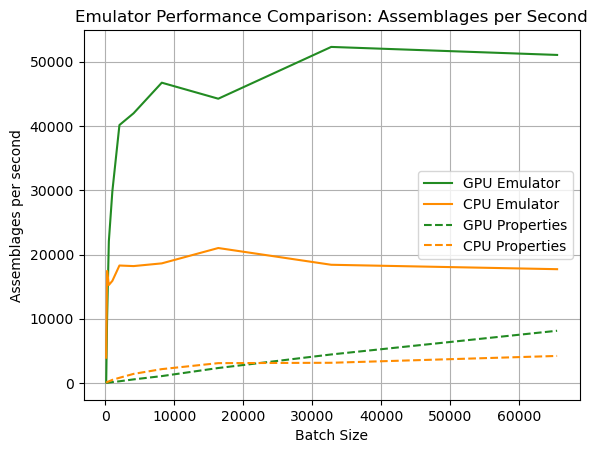

In [4]:

plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_emulator), label='GPU Emulator', color = 'forestgreen', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_emulator), label='CPU Emulator', color = 'darkorange', linestyle='-')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(GPU_properties), label='GPU Properties', color = 'forestgreen', linestyle='--')
plt.plot(batch_sizes, np.array(batch_sizes)/np.array(CPU_properties), label='CPU Properties', color = 'darkorange', linestyle='--')
plt.xlabel('Batch Size')
plt.ylabel('Assemblages per second')
plt.grid(True)
plt.title('Emulator Performance Comparison: Assemblages per Second')
plt.legend()
plt.show()

In [ ]:
generate_phase_diagram(
    coords: np.ndarray,
    phases: np.ndarray,
    phase_names: list[str],
    axis_names: list[str] | None = None,
    *,
    colormap: str = "Purples",
    figsize: tuple[float, float] = (10, 8),
    title: str | None = None,
    ax: "plt.Axes | None" = None,
    small_region_threshold: float = 0.015,
    fontsize: int = 7,
    seed: int = 42,
    boundary_color: str = "white",
    boundary_lw: float = 0.8,
    boundary_alpha: float = 0.6,
    phase_colors: "dict | None" = None,
    apply_tight_layout: bool = True,
) -> tuple["plt.Figure", "plt.Axes"]:

(array([[0.00000000e+00, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [1.10236220e+00, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [2.20472441e+00, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        ...,
        [1.37795276e+02, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [1.38897638e+02, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01],
        [1.40000000e+02, 4.61115980e+00, 1.33196998e+00, ...,
         3.95330012e-01, 5.08000003e-03, 1.53584099e+01]]),
 ['P(GPa)', 'Si', 'Mg', 'Fe', 'Ca', 'Al', 'Na', 'Cr', 'O'])

## Phase Diagrams: Ground Truth vs Emulated (DMM_PS)

Visualize which mineral phases are present across T–P space for the DMM composition,
comparing the HeFESTo ground-truth data loaded in cell 2 against the emulator predictions.

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'DMM_PS — Emulated Phase Diagram'}, xlabel='Temperature (K)', ylabel='Pressure (GPa)'>)

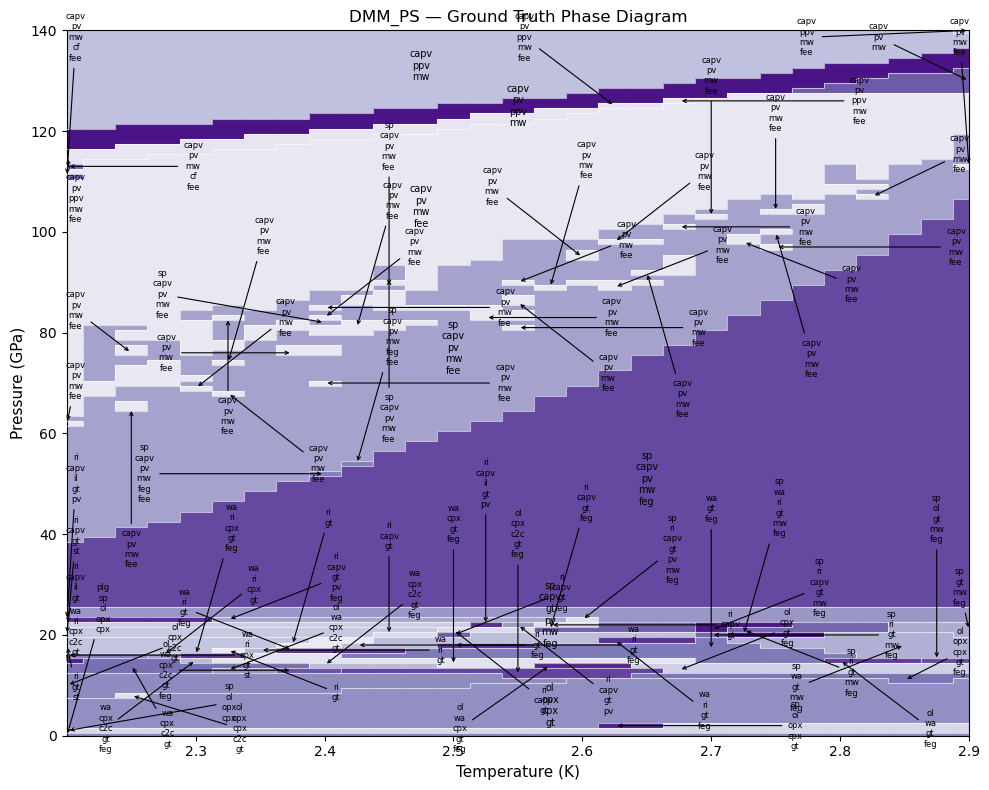

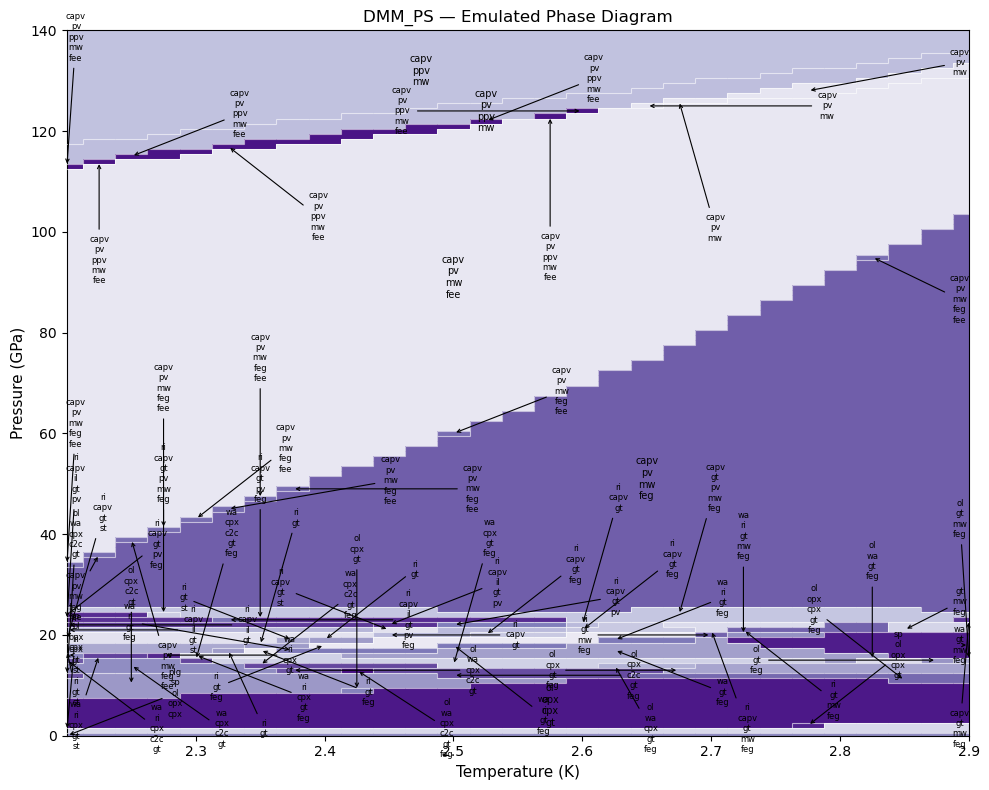

In [10]:
# Phase diagrams: Ground Truth vs Emulated - DMM_PS composition
# Uses generate_phase_diagram() defined in the cell above and
# mass_tables / emulated_mass_tables populated in cell 2.

import numpy as np

def _to_numpy(t):
    if hasattr(t, "detach"):
        return t.detach().cpu().numpy().astype(np.float32)
    return np.asarray(t, dtype=np.float32)

sim_name = "DMM_PS"

coords         = sim_tables[sim_name][["S(J/g/K)", "P(GPa)"]].to_numpy().round(3)
all_phase_names = [REV_HEFESTO_ABBREVIATION_TO_SHORT_NAMES[phase] for phase in list(HeFESToEmulatorCPU.isentropic_emulator.ml_indexer.all_phases)]

gt_phases = (_to_numpy(mass_tables[sim_name])          > 0).astype(int)
em_phases = (_to_numpy(emulated_mass_tables[sim_name]) > 0).astype(int)

generate_phase_diagram(
    coords=coords,
    phases=gt_phases,
    phase_names=all_phase_names,
    title=f"{sim_name} — Ground Truth Phase Diagram",
)

generate_phase_diagram(
    coords=coords,
    phases=em_phases,
    phase_names=all_phase_names,
    title=f"{sim_name} — Emulated Phase Diagram",
)